# Learn a reward model from pairwise preferences

CPU companion; no accelerator is required. TPU execution not validated.

- Represent a preference as a comparison
- Fit score differences with a stable likelihood
- Verify the changed-condition exercise and explain the limits of this fixture.

You know which of two responses is preferred, but you do not have an absolute score for either. How can a model learn from that comparison, and what does its score mean?

## The idea

A pairwise reward model learns to give a preferred item a higher score than its alternative. The loss uses a score difference. That relative objective does not automatically calibrate absolute quality or make preference labels infallible.

## A preference compares scores rather than calibrating utility

If chosen and rejected scores are $3$ and $1$, their margin is $2$. Adding $10$ to both scores leaves the margin unchanged and therefore leaves a difference-based preference loss unchanged. The absolute offset is not identified by those comparisons.

Conflicting labels can make an intermediate preference probability more appropriate than an extreme one. Inspect disagreement and source quality rather than assuming the model should confidently fit every pair.

The margin plot shows separation on the fixture. To support downstream policy optimization, evaluate generalization and possible exploitation separately. A reward that ranks a few training pairs correctly can still be unreliable on policy-generated outputs.

### Pause and reason

Why is a raw reward score of 100 not automatically better calibrated than 1?

<details><summary>Compare your reasoning</summary>

A relative training objective can permit score offsets and depends on the model's conventions. Compare under a shared evaluation contract; raw magnitudes alone are not universal utility units.

</details>

## Before coding: a preference is a comparison

A training example says that one response was preferred to another for the same prompt and rubric. It does not assign a universally meaningful numeric score to either response. Begin by subtracting the rejected score from the chosen score. A positive margin supports the label; a negative margin contradicts it.

The fixture uses three synthetic response feature vectors and three ordered pairs. It teaches comparison likelihood and score identifiability, not human judgment. Keep the prompt/group identity when replacing these vectors with real response representations; comparing unrelated prompts can teach a meaningless ranking.

## Represent a preference as a comparison

Keep the prompt identity, chosen/rejected response identities, label source and split. Pairwise ratings are conditional on a shared prompt and rubric; comparing unrelated prompts can teach a spurious score offset. The fixture has three response feature vectors with an explicit ordering.

## Fit score differences with a stable likelihood

The probability of preferring a chosen response is the sigmoid of its reward difference. The negative log likelihood is softplus of the negative margin. A tied pair starts at $\log 2$. A common offset to all rewards cancels, so comparisons alone do not identify an absolute reward origin.

$$
L_{\mathrm{RM}}=\mathbb E\left[\operatorname{softplus}\!\left(-(r_w(x,y^+)-r_w(x,y^-))\right)\right]
$$

## Calculate likelihood and its derivative

Let $m=r_\theta(x,y^+)-r_\theta(x,y^-)$. The probability of the observed preference is $\sigma(m)$, and its negative log likelihood is $\log(1+e^{-m})$. At margin zero, probability is one half and loss is $\log2$. At margin $\log3$, probability is three quarters and loss is $-\log(3/4)$. The margin derivative is $\sigma(m)-1$: confident correct pairs receive a smaller update than uncertain or wrong pairs.

For a linear score, multiply this derivative by the chosen-minus-rejected feature vector and average pairs. That supplies an independent gradient oracle without differentiating the library softplus implementation.

$$
\nabla_w L=\frac1N\sum_i\left(\sigma(m_i)-1\right)(f_i^+-f_i^-)
$$

## Disagreement changes the optimum

If the same two responses appear once with each preference direction, the average loss is minimized at a tied score, not at infinite confidence in either label. With unequal vote frequencies, the optimum reflects those frequencies under this likelihood model. Collapsing disputed examples into one apparently certain label discards information.

Group train and evaluation splits by prompt/source. Report agreement, likelihood and calibration under the labeling protocol, and inspect disagreements. A scalar metric can hide systematic preferences that conflict between raters or domains. The next policy optimizer will amplify the score signal, so keep a separate evaluator for qualities the reward model may have missed.

## Separate ranking from calibration

Check ordering, held-out pair likelihood and agreement by prompt/source slice. A large positive margin means the model is confident under its likelihood, not that a response is universally good. Separable preferences can drive growing margins; regularization, validation and stopping rules matter even when every training comparison is correct.

## Preserve disagreement and data provenance

Real raters may disagree for legitimate reasons. Retain the rating rubric, task, annotator process and uncertainty instead of converting every disagreement into a perfect label. Split prompts and near-duplicate responses by source so a held-out score does not reward memorization. This lab does not collect personal data or human ratings.

## Keep the reward model fixed during policy evaluation

The next lesson freezes the learned reward while optimizing a policy. If reward changes mid-comparison, observed improvement may reflect a moving evaluator. Retain a reference policy, independent task metrics and adversarial examples to detect reward exploitation.

## Audit both what scores identify and what they do not

Adding one common offset leaves every preference margin unchanged, so pair comparisons cannot identify an absolute zero of reward. Positive scaling preserves ranking but changes probabilities and confidence. The scale also changes the reward-versus-KL tradeoff in policy optimization. Save normalization and model identity when handing scores to the next phase.

A perfectly fitted training ranking can coexist with overconfidence or poor held-out ranking. On separable data the model can keep increasing margins without learning a new ordering. Track weight norms, held-out likelihood and error slices; choose regularization and stopping on development data rather than demanding the smallest possible training loss.

## 1. Define chosen-minus-rejected likelihood

Create main.py in your activated course environment. Paste this block, then run python main.py; function definitions alone print nothing.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np

def preference_loss(w, chosen, rejected):
    margin = (chosen-rejected) @ w
    return jnp.mean(jax.nn.softplus(-margin))

The loss sees feature differences. Predict why adding a common score offset later cannot change it.

## 2. Construct and inspect the three comparisons

Append this block to main.py and run python main.py again. Keep the earlier blocks above it.

In [2]:
features=jnp.array([[1.,0.],[0.,1.],[-1.,-1.]])
chosen=features[jnp.array([0,0,1])];rejected=features[jnp.array([1,2,2])]
w=jnp.zeros(2);history=[]
step=jax.jit(jax.value_and_grad(lambda w:preference_loss(w,chosen,rejected)))

Write the desired order before fitting: response zero above one, and one above two. These labels are synthetic.

## 3. Fit rewards and check their invariances

Append this block to main.py and run python main.py again. Keep the earlier blocks above it.

In [3]:
for _ in range(100):
    value,g=step(w);history.append(float(value));w=w-.1*g
rewards=features@w
assert rewards[0]>rewards[1]>rewards[2]
np.testing.assert_allclose(history[0],np.log(2),atol=1e-6)
assert history[-1]<.1
margins=np.asarray((chosen-rejected)@w,dtype=np.float64)
np.testing.assert_allclose(preference_loss(w,chosen,rejected),np.mean(np.logaddexp(0,-margins)),atol=1e-6)
# Only differences are identified: a common score offset leaves preference probabilities unchanged.
np.testing.assert_allclose(jax.nn.sigmoid((chosen@w+9)-(rejected@w+9)),jax.nn.sigmoid((chosen-rejected)@w),atol=1e-6)
print('Synthetic preference NLL initial/final:',history[0],history[-1],'; rewards:',np.asarray(rewards))

Synthetic preference NLL initial/final: 0.6931471824645996 0.08669456839561462 ; rewards: [ 1.9811294  0.327278  -2.3084073]


The host logaddexp oracle checks stable likelihood values. The score-offset test establishes non-identifiability, not calibration.

## Run the example

In [4]:
import jax
import jax.numpy as jnp
import numpy as np

def preference_loss(w, chosen, rejected):
    margin = (chosen-rejected) @ w
    return jnp.mean(jax.nn.softplus(-margin))

features=jnp.array([[1.,0.],[0.,1.],[-1.,-1.]])
chosen=features[jnp.array([0,0,1])];rejected=features[jnp.array([1,2,2])]
w=jnp.zeros(2);history=[]
step=jax.jit(jax.value_and_grad(lambda w:preference_loss(w,chosen,rejected)))
for _ in range(100):
    value,g=step(w);history.append(float(value));w=w-.1*g
rewards=features@w
assert rewards[0]>rewards[1]>rewards[2]
np.testing.assert_allclose(history[0],np.log(2),atol=1e-6)
assert history[-1]<.1
margins=np.asarray((chosen-rejected)@w,dtype=np.float64)
np.testing.assert_allclose(preference_loss(w,chosen,rejected),np.mean(np.logaddexp(0,-margins)),atol=1e-6)
# Only differences are identified: a common score offset leaves preference probabilities unchanged.
np.testing.assert_allclose(jax.nn.sigmoid((chosen@w+9)-(rejected@w+9)),jax.nn.sigmoid((chosen-rejected)@w),atol=1e-6)
print('Synthetic preference NLL initial/final:',history[0],history[-1],'; rewards:',np.asarray(rewards))


Synthetic preference NLL initial/final: 0.6931471824645996 0.08669456839561462 ; rewards: [ 1.9811294  0.327278  -2.3084073]


Expected: The model learns all three declared preferences; common reward offsets preserve probabilities.

## Learn a reward model from pairwise preferences — recorded experiment

Predict: Which final comparison margin should be the largest given the ordering zero above one above two?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
visual_data={'kind':'line','xlabel':'completed parameter updates before measurement','ylabel':'pairwise preference NLL (nats)','series':[{'label':'recorded CPU training loss','x':list(range(len(history))),'y':history}]}
for panel in visual_data.get('panels',[visual_data]):
    panel['x']=panel['series'][0]['x']

extra_panel={'kind':'bar','x':[0,1,2],'labels':['0 preferred to 1','0 preferred to 2','1 preferred to 2'],'series':[{'label':'final score difference','y':np.asarray((chosen-rejected)@w).tolist()}],'xlabel':'synthetic comparison','ylabel':'chosen minus rejected reward','title':'Which comparisons the reward model fitted'}
visual_data={"panels":[*visual_data.get("panels",[visual_data]),extra_panel]}


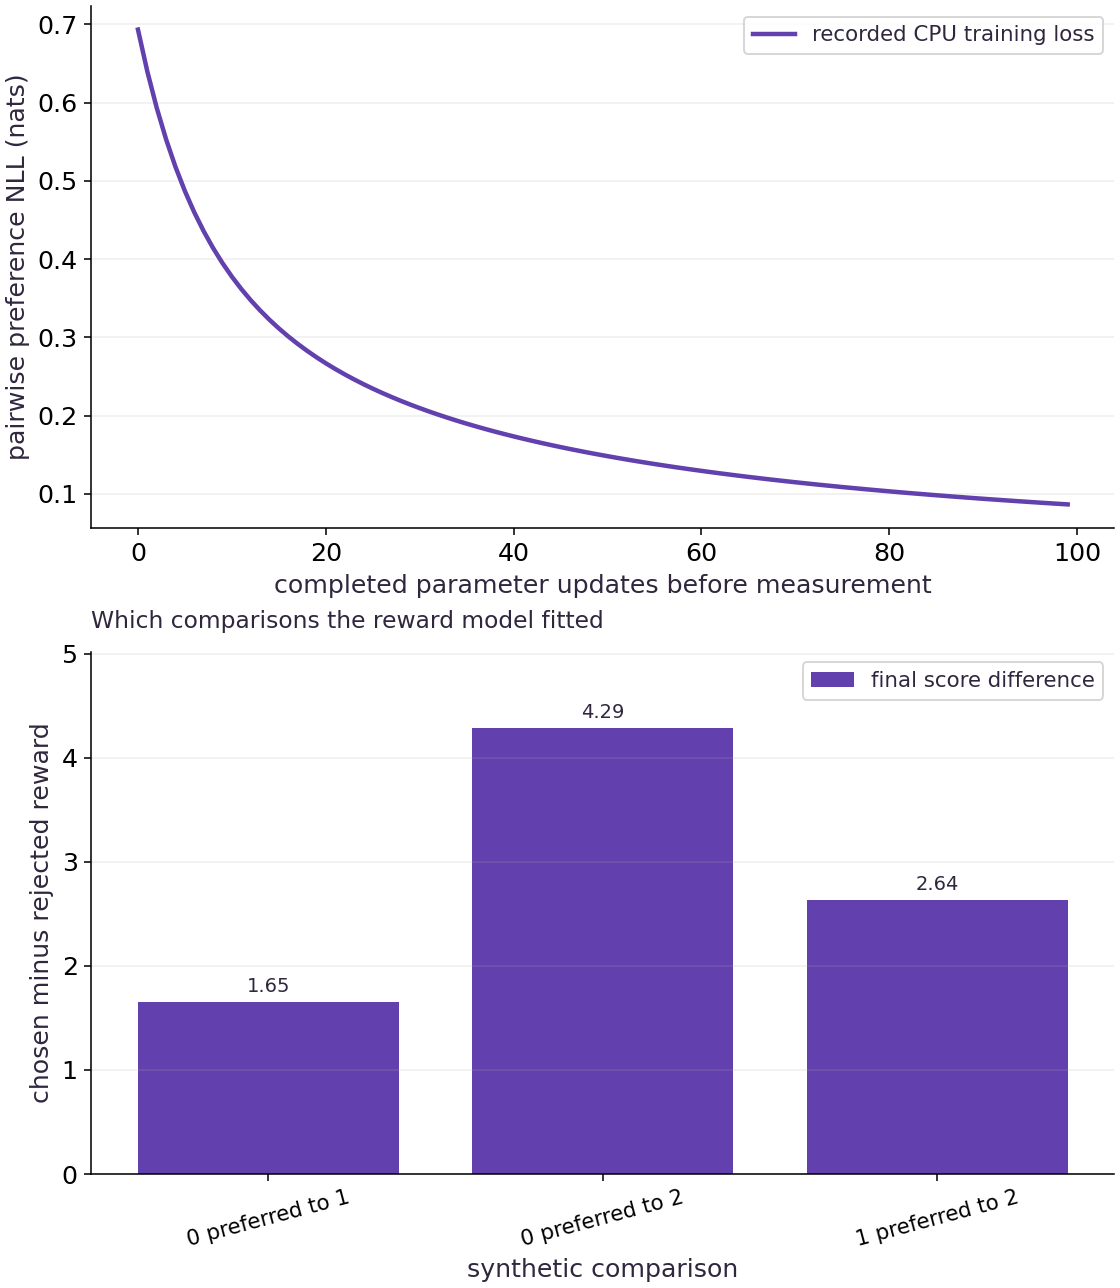

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The vertical axis is pairwise negative log likelihood in nats. It starts near $0.693=\log2$, then falls to about $0.087$. Each point is before an update on the same three synthetic comparisons; it is not a human agreement rate.

The second panel reports final chosen-minus-rejected score margins for the three training comparisons. All are positive, so each ordering agrees with its synthetic label. The zero-versus-two comparison spans the other two and has the largest margin. A common reward offset would leave every bar unchanged; multiplying weights by two would double them without changing ordering. Neither operation is visible in a ranking-only accuracy number.

### Connect it to the computation

The initial zero weights tie all response scores. Training increases the chosen-minus-rejected margins. The offset and scaling exercises explain why reward values must be interpreted relative to their model and downstream objective.

## Reverse the comparison

Predict: How should a positive margin change when chosen and rejected responses swap?

In [7]:
forward=float(preference_loss(w,chosen,rejected))
reverse=float(preference_loss(w,rejected,chosen))
assert reverse>forward
print('Forward/reversed preference NLL:',forward,reverse)

Forward/reversed preference NLL: 0.08596369624137878 2.94565486907959


Expected: The reversed-label loss is larger.

This checks label direction. A decreasing incorrectly signed loss can train a consistent but reversed preference model.

## Fit conflicting labels conceptually

Predict: If a pair is labeled both ways equally often, should the best margin be positive, negative or zero?

In [8]:
conflict=lambda margin:.5*(jax.nn.softplus(-margin)+jax.nn.softplus(margin))
np.testing.assert_allclose(conflict(0.),np.log(2),atol=1e-6)
np.testing.assert_allclose(jax.grad(conflict)(0.),0.,atol=1e-7)
assert float(conflict(2.))>float(conflict(0.))
np.testing.assert_allclose(conflict(2.),conflict(-2.))
print('Balanced conflicting labels prefer a zero margin.')

Balanced conflicting labels prefer a zero margin.


Expected: Zero margin minimizes the balanced contradictory-pair objective.

Disagreement is not fixed by flipping labels until training accuracy is high. The likelihood must represent the information actually present.

## Your exercise

Calculate the initial loss for tied reward scores independently and verify the trained ordering.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
np.testing.assert_allclose(preference_loss(jnp.zeros(2),chosen,rejected),-np.log(.5),atol=1e-6)
assert np.all(np.asarray((chosen-rejected)@w)>0)
print('Tied baseline and preference directions verified.')

Tied baseline and preference directions verified.


## Show that feature scale can change scores without changing ranking · Transfer

Multiply the trained reward weights by two and compare ordering and preference probabilities.

Hint: Positive scaling preserves ordering but sharpens probabilities.

In [11]:
# Write your attempt here.

## Reference reasoning

A policy’s reward-versus-KL tradeoff depends on reward scale. Rank agreement alone cannot establish an equivalent RL objective.

In [12]:
scaled_rewards=features@(2*w)
np.testing.assert_array_equal(np.argsort(rewards),np.argsort(scaled_rewards))
assert float(preference_loss(2*w,chosen,rejected))<float(preference_loss(w,chosen,rejected))
print('Ranking unchanged; confidence and downstream reward scale change.')

Ranking unchanged; confidence and downstream reward scale change.


## Derive the linear reward gradient · Challenge

At a fresh weight vector, calculate the mean feature difference weighted by probability-minus-one and compare with autodiff. Repeat after reversing labels.

Hint: Use NumPy sigmoid values for the independent calculation; reversing both feature order and probabilities is necessary.

In [13]:
# Write your attempt here.

## Reference reasoning

Checking both directions catches a sign error that a single decreasing training curve might conceal.

In [14]:
probe_w=jnp.array([.2,-.4])
for positive,negative in [(chosen,rejected),(rejected,chosen)]:
 difference=np.asarray(positive-negative,dtype=np.float64)
 margin_host=difference@np.asarray(probe_w)
 analytic=np.mean((1/(1+np.exp(-margin_host))-1)[:,None]*difference,axis=0)
 np.testing.assert_allclose(jax.grad(preference_loss)(probe_w,positive,negative),analytic,atol=1e-6)
print('Independent reward gradients agree in both label directions.')

Independent reward gradients agree in both label directions.


## Checkpoint

What do pairwise preferences identify directly?

1. Reward differences under the chosen comparison model, not an absolute universal utility.
2. A lower training loss by itself proves the full application is ready.
3. Matching shapes alone establishes the required behavior.

## Diagnose

If margins have the wrong sign, inspect chosen/rejected order. If training ranking is perfect but held-out agreement fails, inspect prompt leakage, rubric consistency and reward-model overfitting.

## Evidence

Keep synthetic label provenance, stable preference-loss and gradient references, offset/scale tests and the learned ordering.

## Carry forward

- Let $m=r_\theta(x,y^+)-r_\theta(x,y^-)$. The probability of the observed preference is $\sigma(m)$, and its negative log likelihood is $\log(1+e^{-m})$. At margin zero, probability is one half and loss is $\log2$. At margin $\log3$, probability is three quarters and loss is $-\log(3/4)$. The margin derivative is $\sigma(m)-1$: confident correct pairs receive a smaller update than uncertain or wrong pairs.
- Adding one common offset leaves every preference margin unchanged, so pair comparisons cannot identify an absolute zero of reward. Positive scaling preserves ranking but changes probabilities and confidence. The scale also changes the reward-versus-KL tradeoff in policy optimization. Save normalization and model identity when handing scores to the next phase.

## Primary references

- [InstructGPT: reward modeling from preferences](https://arxiv.org/abs/2203.02155)